<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S4_U4_Clase7_Laboratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Minería de Datos — Unidad 4: Visualización de Datos
## Laboratorio Clase 7 · Matplotlib y Seaborn

**Tecnicatura Superior en Cs de Datos e IA**  
**Politécnico Malvinas Argentinas · 2026**

---

Este notebook tiene **dos partes**:

1. **Parte Demostrativa** — Ejemplos comentados que el docente ejecuta en clase. Observá, experimentá y tomá notas.
2. **Actividades para el Foro** — Ejercicios que debés completar y compartir en el foro de Moodle antes de la Clase 9.

> **Nota sobre la evaluación:** Esta actividad corresponde a *Participación en foro a través de notebook de ejercitación*. No es una entrega individual calificada numéricamente, sino una contribución al aprendizaje colaborativo del grupo.


---
# PARTE 1 — Demostración en Clase

> Estos ejemplos se ejecutan y explican durante la clase. Podés modificarlos para experimentar.


## 1.1 Configuración del Entorno

In [ ]:
# Instalación (solo necesario en Colab)
# !pip install seaborn --quiet

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración global de estilo
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Librerías cargadas correctamente")
print(f"   matplotlib: {plt.matplotlib.__version__}")
print(f"   seaborn:    {sns.__version__}")
print(f"   pandas:     {pd.__version__}")


✅ Librerías cargadas correctamente
   matplotlib: 3.10.0
   seaborn:    0.13.2
   pandas:     2.2.2


               x          y
count  44.000000  44.000000
mean    9.000000   7.500682
std     3.198837   1.958925
min     4.000000   3.100000
25%     7.000000   6.117500
50%     8.000000   7.520000
75%    11.000000   8.747500
max    19.000000  12.740000


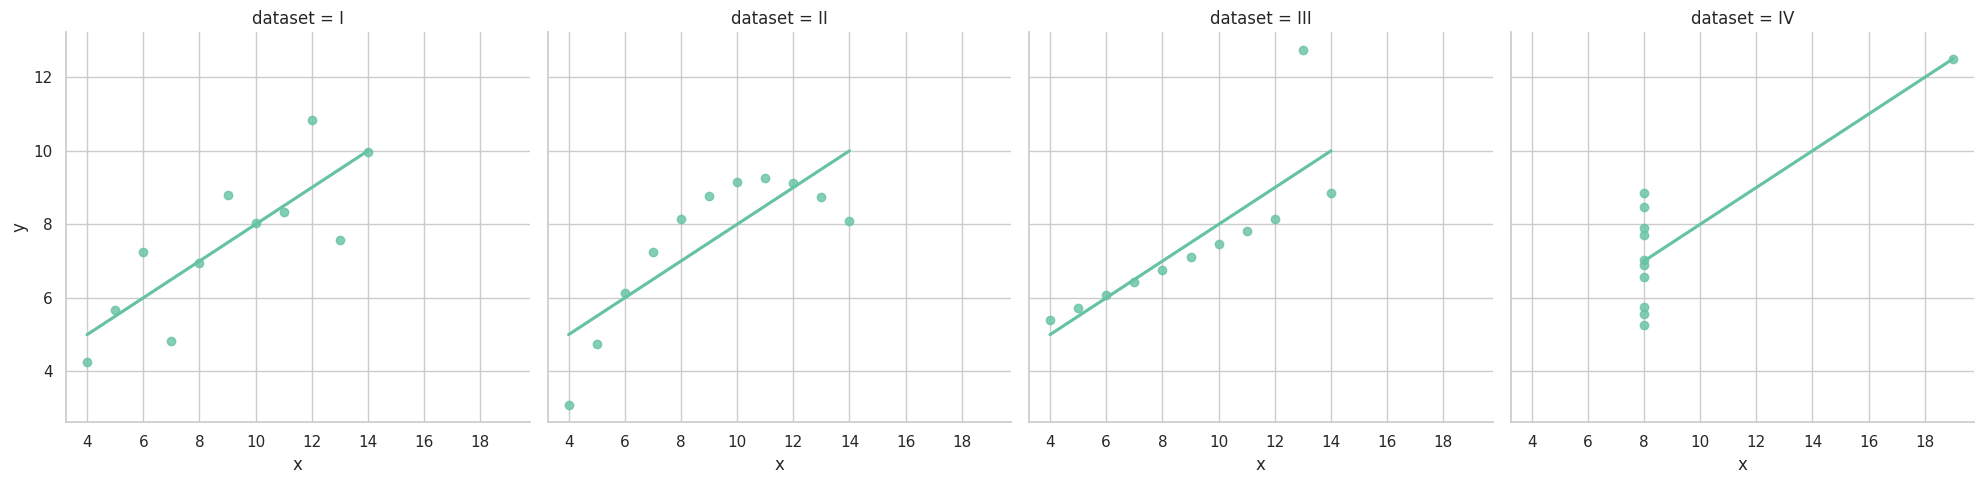

In [ ]:
ds = sns.load_dataset('anscombe')
print(ds.describe())
sns.lmplot(data=ds, x='x', y='y', col='dataset', ci=None)
plt.show()

## 1.2 Carga de Datasets de Trabajo

Usamos tres datasets integrados en Seaborn que ya conocen:
- **titanic** → pasajeros del Titanic (supervivencia, edad, clase, tarifa)
- **tips** → propinas en un restaurante (monto total, propina, día, hora, tamaño del grupo)
- **iris** → medidas de flores (sépalos y pétalos por especie)


In [ ]:
# Cargar los tres datasets
titanic = sns.load_dataset('titanic')
tips    = sns.load_dataset('tips')
iris    = sns.load_dataset('iris')

print("=== TITANIC ===")
print(titanic.shape, "\n", titanic.dtypes.to_string())
print("\n=== TIPS ===")
print(tips.shape, "\n", tips.dtypes.to_string())
print("\n=== IRIS ===")
print(iris.shape, "\n", iris.dtypes.to_string())


=== TITANIC ===
(891, 15) 
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool

=== TIPS ===
(244, 7) 
 total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64

=== IRIS ===
(150, 5) 
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object


## 1.3 ¿Por Qué Visualizar? — El Cuarteto de Anscombe

Cuatro datasets con **estadísticas descriptivas idénticas** pero distribuciones completamente distintas.  
Este ejemplo demuestra que las estadísticas numéricas solas son insuficientes: **siempre hay que graficar**.


In [ ]:
# Cargar el dataset de Anscombe
anscombe = sns.load_dataset('anscombe')

# Verificar que las estadísticas son IDÉNTICAS para los 4 datasets
print("Estadísticas por dataset:")
print(anscombe.groupby('dataset')[['x', 'y']].agg(['mean', 'std']).round(2))


Estadísticas por dataset:
           x          y      
        mean   std mean   std
dataset                      
I        9.0  3.32  7.5  2.03
II       9.0  3.32  7.5  2.03
III      9.0  3.32  7.5  2.03
IV       9.0  3.32  7.5  2.03


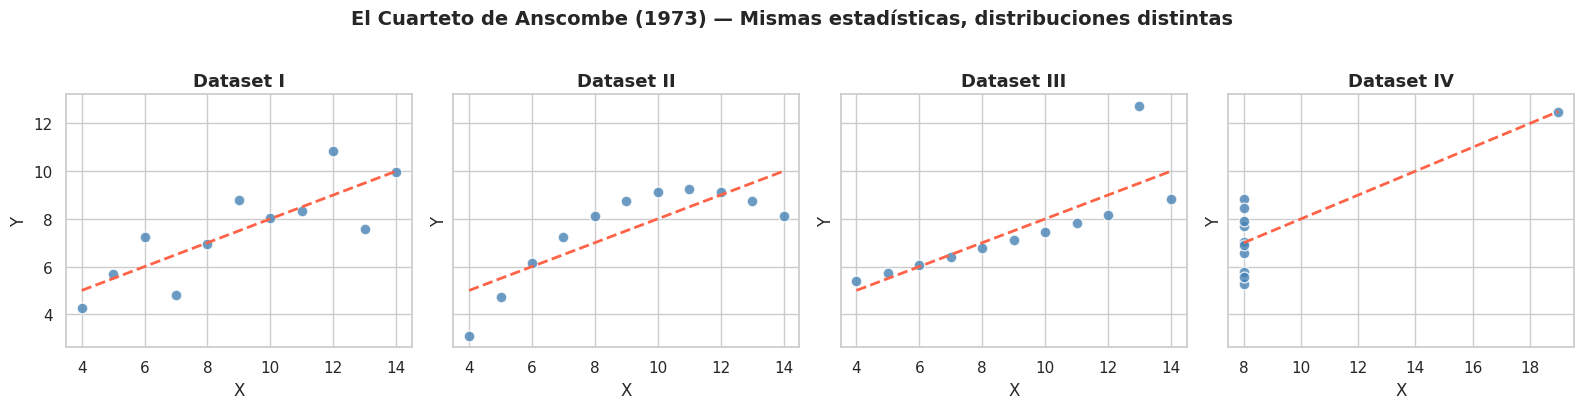


⚠  Moraleja: Una correlación r=0.816 puede ocultar patrones muy diferentes.
   Siempre visualizá los datos antes de modelar.


In [ ]:
# Graficar los 4 datasets — aquí se ve la DIFERENCIA real
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, (name, group) in zip(axes, anscombe.groupby('dataset')):
    ax.scatter(group['x'], group['y'], color='steelblue', s=60, alpha=0.8, edgecolors='white')
    # Línea de regresión manual
    m, b = np.polyfit(group['x'], group['y'], 1)
    x_line = np.linspace(group['x'].min(), group['x'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', lw=2, linestyle='--')
    ax.set_title(f'Dataset {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

fig.suptitle('El Cuarteto de Anscombe (1973) — Mismas estadísticas, distribuciones distintas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠  Moraleja: Una correlación r=0.816 puede ocultar patrones muy diferentes.")
print("   Siempre visualizá los datos antes de modelar.")


## 1.4 Arquitectura de Matplotlib — Figure y Axes

Matplotlib organiza los gráficos en una jerarquía:
- **Figure** → el "papel" completo (puede contener varios subplots)
- **Axes** → un subplot individual (tiene sus propios ejes, título, datos)
- **Artist** → todo lo visible: líneas, puntos, texto, barras

Usamos la **interfaz orientada a objetos (OO)** con `fig, ax = plt.subplots()` porque es la forma más clara y recomendada.


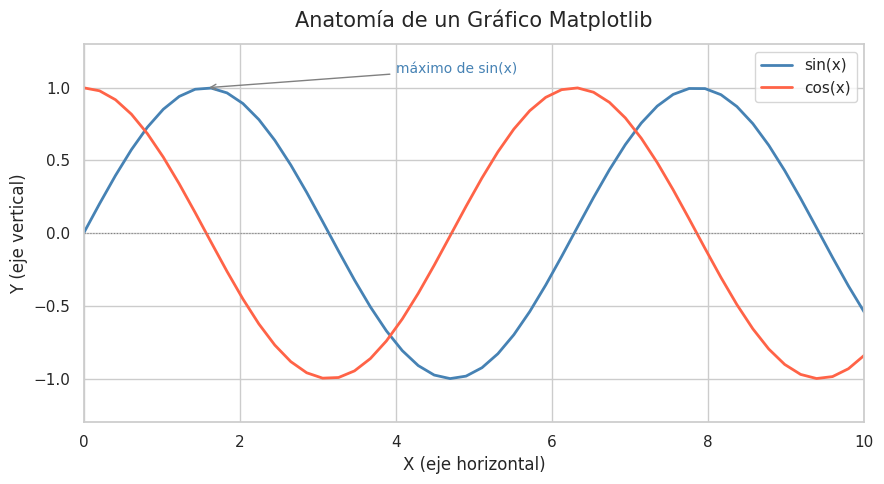

In [ ]:
# Demostración de la interfaz OO — anatomía de un gráfico
fig, ax = plt.subplots(figsize=(9, 5))

# Datos de ejemplo
x = np.linspace(0, 10, 50)
y1 = np.sin(x)
y2 = np.cos(x)

ax.plot(x, y1, color='steelblue', lw=2,  label='sin(x)')    # Artist: Line2D
ax.plot(x, y2, color='tomato',    lw=2,  label='cos(x)')    # Artist: Line2D

# Personalización explícita a través del objeto Axes
ax.set_title('Anatomía de un Gráfico Matplotlib', fontsize=15, pad=12)
ax.set_xlabel('X (eje horizontal)', fontsize=12)
ax.set_ylabel('Y (eje vertical)',    fontsize=12)
ax.legend(fontsize=11)
ax.axhline(0, color='gray', lw=0.8, linestyle=':')  # línea de referencia y=0
ax.set_xlim(0, 10)
ax.set_ylim(-1.3, 1.3)

# Anotación en el gráfico
ax.annotate('máximo de sin(x)', xy=(np.pi/2, 1), xytext=(4, 1.1),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='steelblue')

plt.tight_layout()
plt.show()


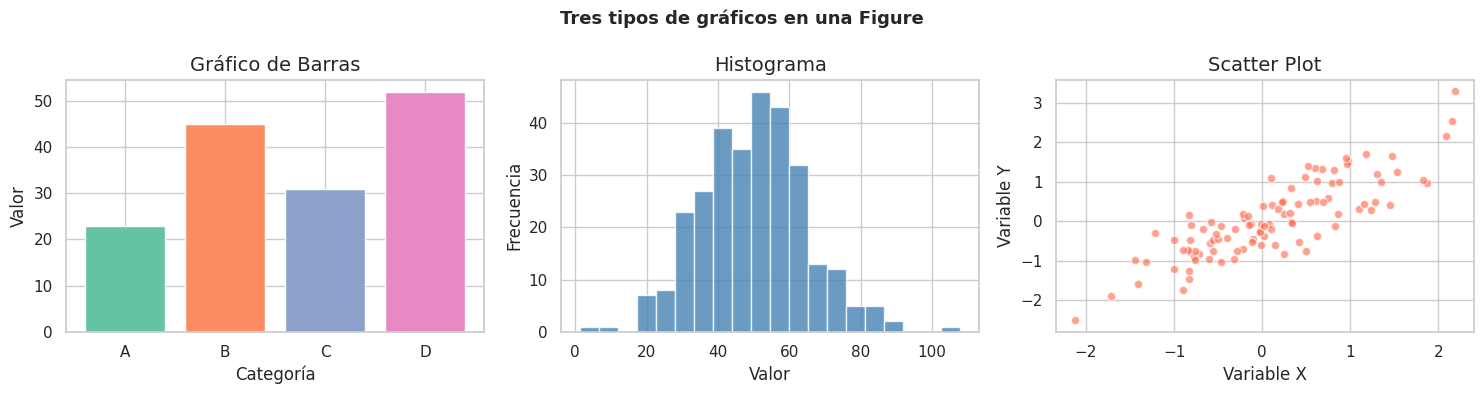

In [ ]:
# Múltiples subplots con plt.subplots()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subplot 1: gráfico de barras
categorias = ['A', 'B', 'C', 'D']
valores = [23, 45, 31, 52]
axes[0].bar(categorias, valores, color=sns.color_palette('Set2', 4))
axes[0].set_title('Gráfico de Barras')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Valor')

# Subplot 2: histograma
np.random.seed(42)
datos = np.random.normal(50, 15, 300)
axes[1].hist(datos, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Histograma')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')

# Subplot 3: scatter plot
x_rand = np.random.randn(100)
y_rand = x_rand * 0.8 + np.random.randn(100) * 0.5
axes[2].scatter(x_rand, y_rand, alpha=0.6, color='tomato', edgecolors='white')
axes[2].set_title('Scatter Plot')
axes[2].set_xlabel('Variable X')
axes[2].set_ylabel('Variable Y')

plt.suptitle('Tres tipos de gráficos en una Figure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1.5 El Histograma — Distribución de una Variable Continua

El histograma divide el rango de valores en **bins** (intervalos) y cuenta cuántos valores caen en cada uno.  
Responde: *¿cómo se distribuyen los valores de esta variable?*

**Parámetros clave:**
- `bins`: cantidad de intervalos (más bins = más detalle, más ruido)
- `kde=True` (Seaborn): superpone la curva KDE (Kernel Density Estimation)
- `stat='density'`: normaliza para comparar distribuciones de distinto tamaño


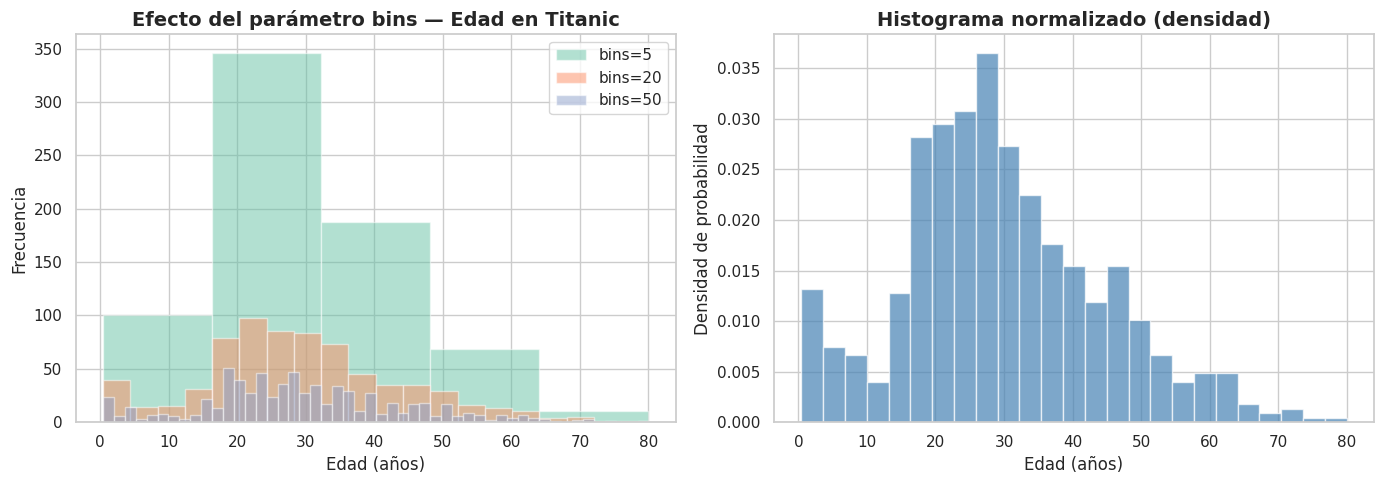

In [ ]:
# Histograma con Matplotlib (interfaz OO)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — efecto del parámetro bins
for bins, color in zip([5, 20, 50], ['#2196F3', '#4CAF50', '#FF5722']):
    axes[0].hist(titanic['age'].dropna(), bins=bins, alpha=0.5,
                 label=f'bins={bins}', edgecolor='white')
axes[0].set_title('Efecto del parámetro bins — Edad en Titanic', fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Panel derecho — histograma normalizado con frecuencia relativa
axes[1].hist(titanic['age'].dropna(), bins=25, color='steelblue',
             edgecolor='white', density=True, alpha=0.7)
axes[1].set_title('Histograma normalizado (densidad)', fontweight='bold')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Densidad de probabilidad')

plt.tight_layout()
plt.show()


La media, la media na y la moda.... (ver propiedades de la curva normal)
Texto agregado por mi

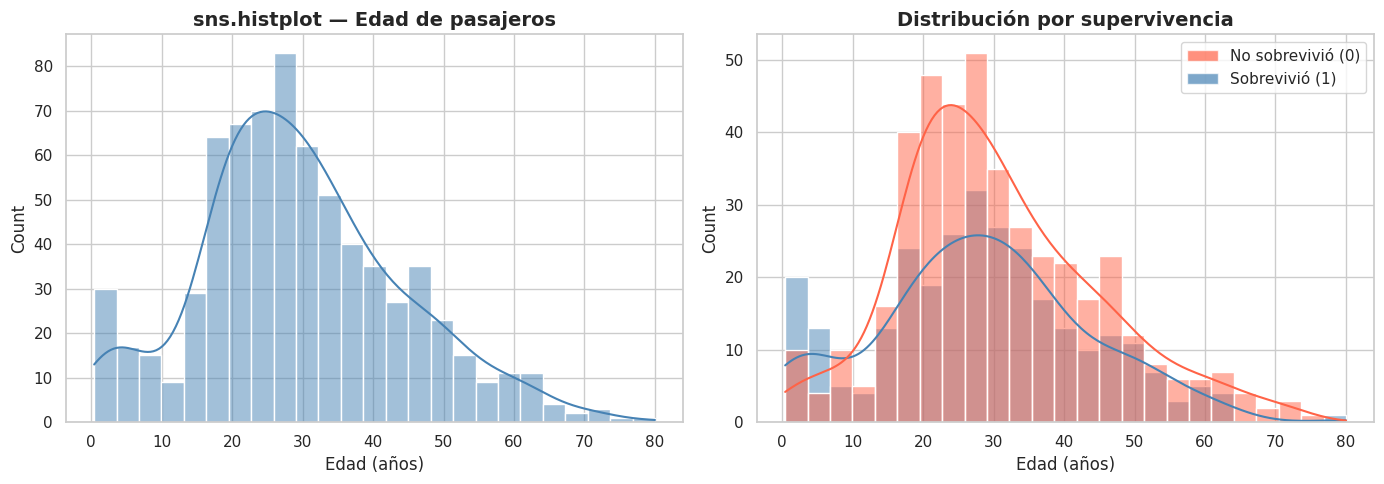

Observación: ¿Los niños (edad < 10) tuvieron mayor tasa de supervivencia?
age
>=10 años    0.366707
<10 años     0.612903
Name: survived, dtype: float64


In [ ]:
# Histograma con Seaborn — histplot con KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — histplot básico con KDE
sns.histplot(data=titanic, x='age', bins=25, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('sns.histplot — Edad de pasajeros', fontweight='bold')
axes[0].set_xlabel('Edad (años)')

# Panel derecho — histplot por grupos (hue)
sns.histplot(data=titanic, x='age', hue='survived', bins=25,
             kde=True, palette={0: 'tomato', 1: 'steelblue'},
             alpha=0.5, ax=axes[1])
axes[1].set_title('Distribución por supervivencia', fontweight='bold')
axes[1].set_xlabel('Edad (años)')

# Actualizar leyenda manualmente
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', alpha=0.7, label='No sobrevivió (0)'),
                   Patch(facecolor='steelblue', alpha=0.7, label='Sobrevivió (1)')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("Observación: ¿Los niños (edad < 10) tuvieron mayor tasa de supervivencia?")
print(titanic.groupby(titanic['age'] < 10)['survived'].mean().rename({True: '<10 años', False: '>=10 años'}))


## 1.6 El Boxplot — Quartiles y Outliers

El boxplot resume **5 estadísticas** en un gráfico:
- **Q1 (P25)** → borde inferior de la caja
- **Mediana (Q2)** → línea central
- **Q3 (P75)** → borde superior de la caja
- **Bigotes** → se extienden hasta 1.5 × IQR desde Q1 y Q3
- **Puntos fuera** → outliers

Ideal para **comparar la distribución entre grupos**.


/tmp/ipykernel_21649/2380547363.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(clases.values(), labels=clases.keys(),


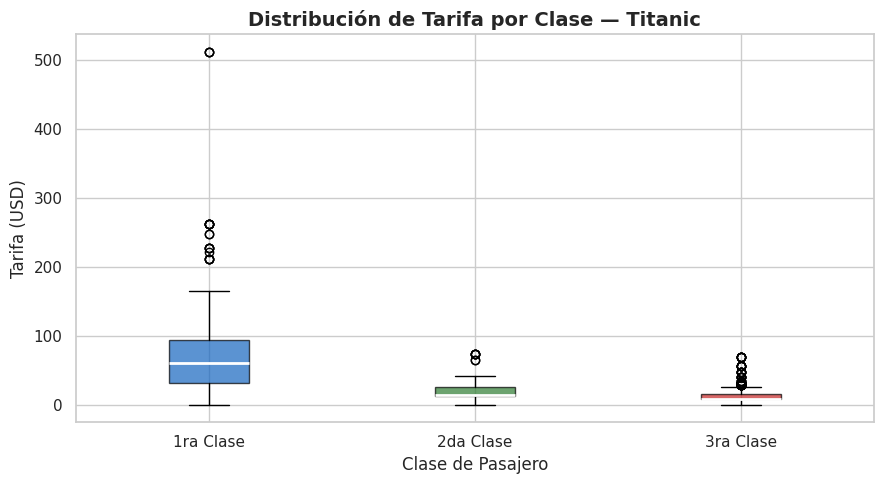

In [ ]:
# Boxplot con Matplotlib
fig, ax = plt.subplots(figsize=(9, 5))

# Extraer datos por clase del Titanic
clases = {
    '1ra Clase': titanic[titanic['pclass']==1]['fare'].dropna(),
    '2da Clase': titanic[titanic['pclass']==2]['fare'].dropna(),
    '3ra Clase': titanic[titanic['pclass']==3]['fare'].dropna(),
}

bp = ax.boxplot(clases.values(), labels=clases.keys(),
                patch_artist=True, notch=False,
                medianprops=dict(color='white', lw=2))

# Colorear cajas
colores = ['#1565C0', '#2E7D32', '#C62828']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribución de Tarifa por Clase — Titanic', fontweight='bold')
ax.set_ylabel('Tarifa (USD)')
ax.set_xlabel('Clase de Pasajero')
plt.tight_layout()
plt.show()


/tmp/ipykernel_21649/873229321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='pclass', y='fare',


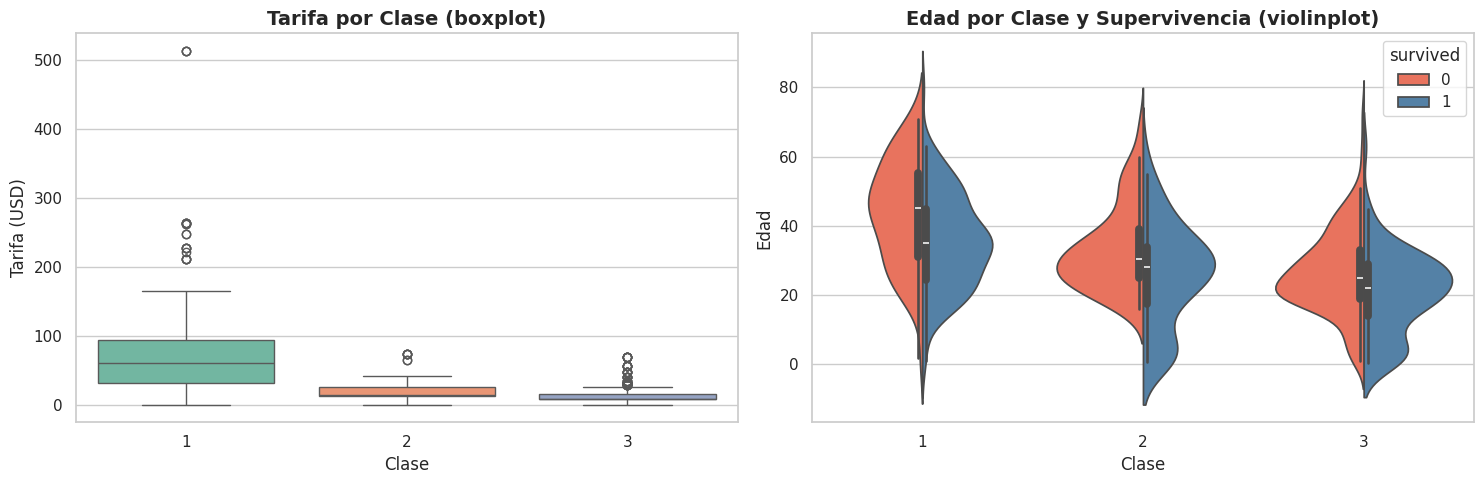


📌 El violinplot combina boxplot + KDE.
   split=True divide el violin por la variable hue en dos mitades.


In [ ]:
# Boxplot con Seaborn — mucho más simple para grupos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot de tarifa por clase
sns.boxplot(data=titanic, x='pclass', y='fare',
            palette='Set2', ax=axes[0])
axes[0].set_title('Tarifa por Clase (boxplot)', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Tarifa (USD)')

# Violinplot — muestra también la FORMA de la distribución
sns.violinplot(data=titanic, x='pclass', y='age',
               hue='survived', split=True,
               palette={0: 'tomato', 1: 'steelblue'}, ax=axes[1])
axes[1].set_title('Edad por Clase y Supervivencia (violinplot)', fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

print("\n📌 El violinplot combina boxplot + KDE.")
print("   split=True divide el violin por la variable hue en dos mitades.")


## 1.7 Scatter Plot — Relación entre Dos Variables

Cada punto representa una **observación**. La posición X/Y indica los valores de dos variables numéricas.  
Revela correlaciones, clusters, outliers y patrones no lineales.

> ⚠ **Correlación ≠ Causalidad**: que dos variables estén correlacionadas no significa que una cause la otra.


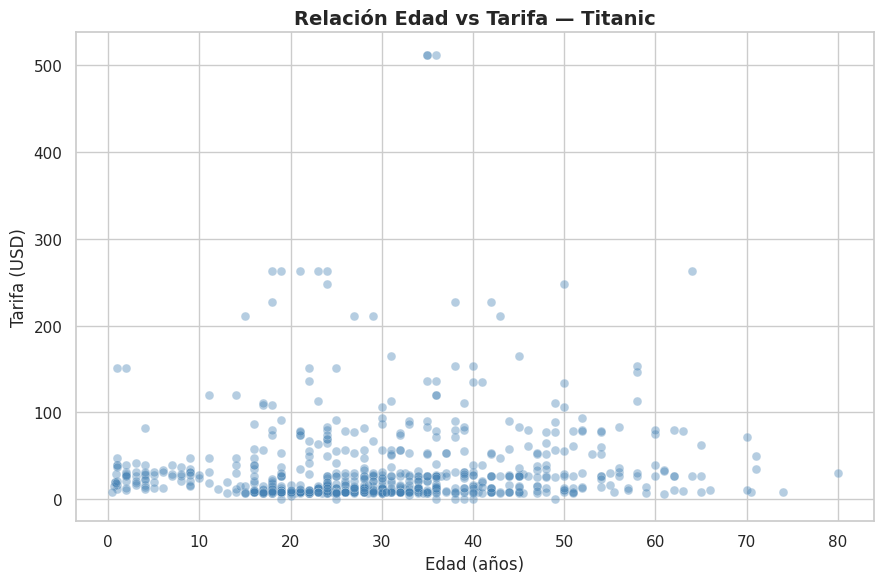

Correlación de Pearson (edad, tarifa): 0.096
¿Qué nos dice esta correlación sobre la relación entre edad y precio del pasaje?


In [ ]:
# Scatter plot con Matplotlib
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(titanic['age'], titanic['fare'],
           alpha=0.4, s=40,
           color='steelblue', edgecolors='white', lw=0.3)
ax.set_title('Relación Edad vs Tarifa — Titanic', fontweight='bold')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Tarifa (USD)')
plt.tight_layout()
plt.show()

# Calcular correlación
corr = titanic[['age', 'fare']].corr().iloc[0, 1]
print(f"Correlación de Pearson (edad, tarifa): {corr:.3f}")
print("¿Qué nos dice esta correlación sobre la relación entre edad y precio del pasaje?")


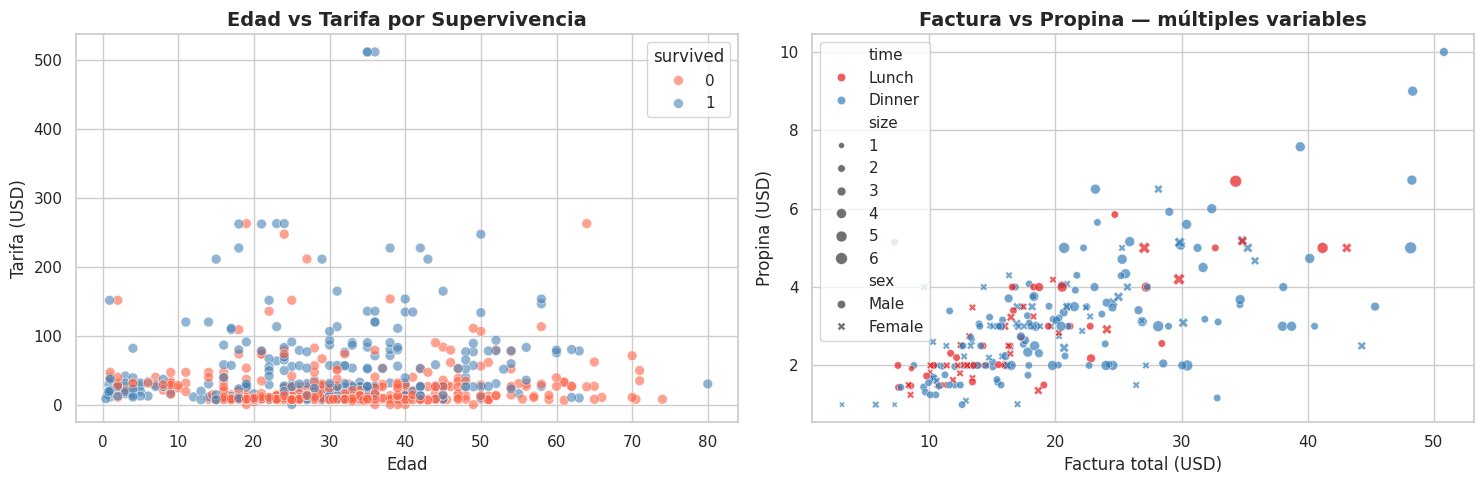

In [ ]:
# Scatter plot con Seaborn — hue, size y estilo automáticos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo — scatterplot con hue por supervivencia
sns.scatterplot(data=titanic, x='age', y='fare',
                hue='survived', palette={0: 'tomato', 1: 'steelblue'},
                alpha=0.6, s=50, ax=axes[0])
axes[0].set_title('Edad vs Tarifa por Supervivencia', fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Tarifa (USD)')

# Panel derecho — scatterplot en tips con múltiples dimensiones
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='time', size='size', style='sex',
                palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Factura vs Propina — múltiples variables', fontweight='bold')
axes[1].set_xlabel('Factura total (USD)')
axes[1].set_ylabel('Propina (USD)')

plt.tight_layout()
plt.show()


## 1.8 Pairplot — Relaciones entre Múltiples Variables

`sns.pairplot()` genera una **matriz de scatter plots** para todas las combinaciones de variables numéricas.  
La diagonal muestra la distribución de cada variable individual.


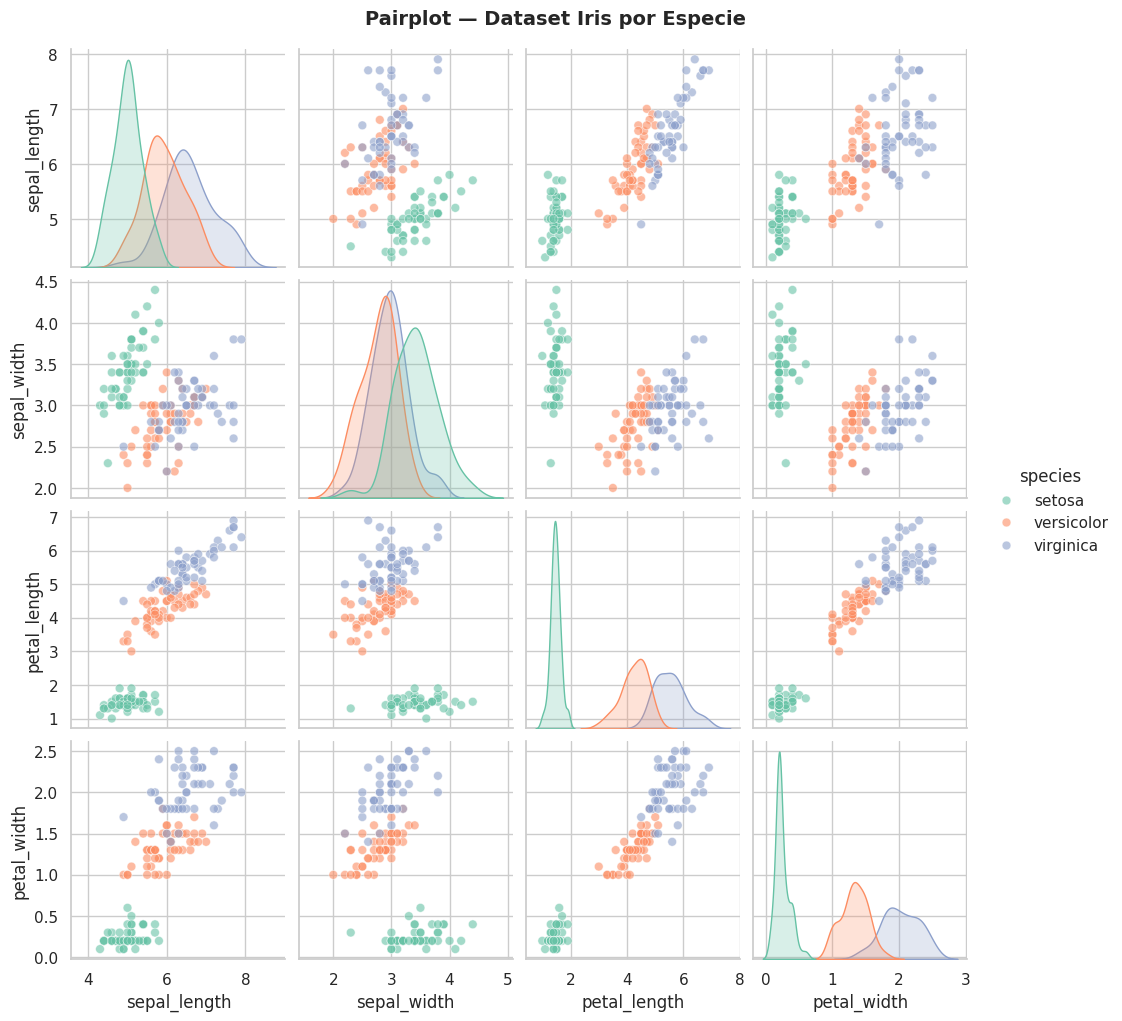


Observaciones del pairplot:
- ¿Qué par de variables separa mejor las especies?
- ¿Hay alguna especie que sea difícil de separar de las demás?


In [ ]:
# Pairplot del dataset Iris
g = sns.pairplot(iris, hue='species',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40},
                 palette='Set2')
g.fig.suptitle('Pairplot — Dataset Iris por Especie', y=1.02,
               fontsize=14, fontweight='bold')
plt.show()

print("\nObservaciones del pairplot:")
print("- ¿Qué par de variables separa mejor las especies?")
print("- ¿Hay alguna especie que sea difícil de separar de las demás?")


## 1.9 Heatmap de Correlación

Visualiza la **matriz de correlación** entre todas las variables numéricas.  
- Rojo/azul oscuro → correlación positiva/negativa fuerte
- Blanco → sin correlación
- La diagonal siempre vale 1.0


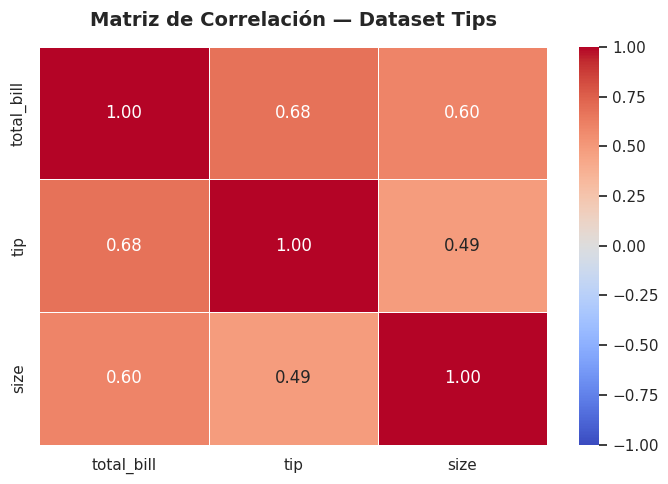


¿Cuáles son las dos variables más correlacionadas?
¿Tiene sentido esa correlación desde el punto de vista del dominio?


In [ ]:
# Calcular y visualizar la matriz de correlación del dataset tips
corr_matrix = tips.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            linewidths=0.5,
            ax=ax)
ax.set_title('Matriz de Correlación — Dataset Tips', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n¿Cuáles son las dos variables más correlacionadas?")
print("¿Tiene sentido esa correlación desde el punto de vista del dominio?")


## 1.10 Estilos y Paletas de Colores en Seaborn

Seaborn ofrece estilos y paletas de colores para hacer los gráficos más legibles y visualmente agradables.


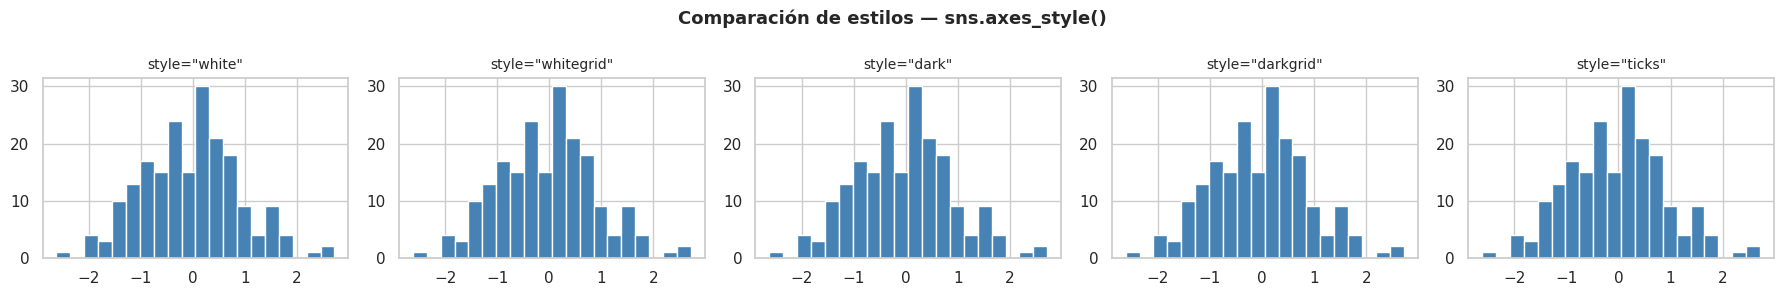

In [ ]:
# Comparación de estilos de Seaborn
estilos = ['white', 'whitegrid', 'dark', 'darkgrid', 'ticks']
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

np.random.seed(42)
datos = np.random.normal(0, 1, 200)

for ax, estilo in zip(axes, estilos):
    with sns.axes_style(estilo):
        ax_inner = ax
        ax_inner.hist(datos, bins=20, color='steelblue', edgecolor='white')
        ax_inner.set_title(f'style="{estilo}"', fontsize=10)
        ax_inner.set_xlabel('')
        ax_inner.set_ylabel('')

plt.suptitle('Comparación de estilos — sns.axes_style()', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


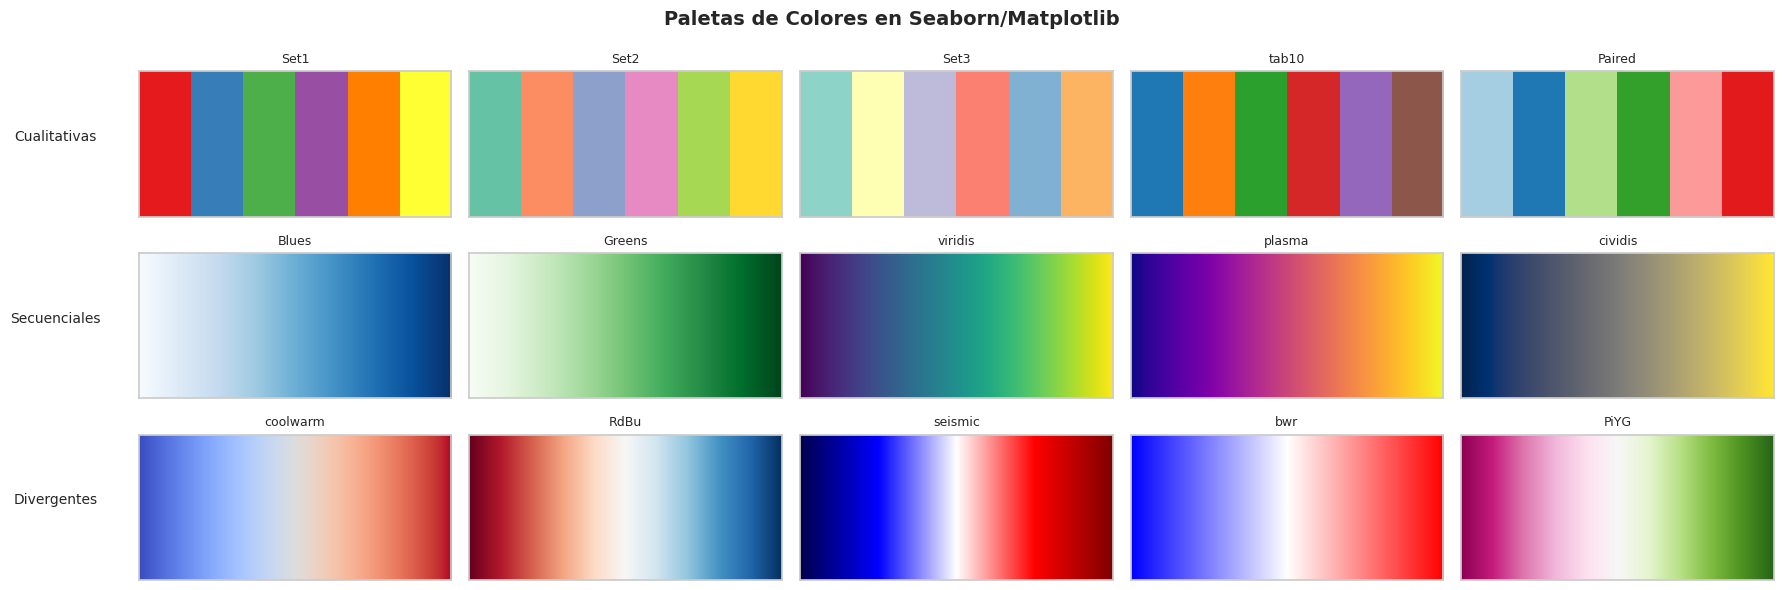


📌 Guía de selección de paleta:
   Cualitativa → variables categóricas sin orden (colores distintos)
   Secuencial  → variable numérica de menor a mayor (gradiente de un color)
   Divergente  → variable numérica con punto neutro (rojo-blanco-azul)


In [ ]:
# Exploración de paletas de colores
paletas_cualitativas  = ['Set1', 'Set2', 'Set3', 'tab10', 'Paired']
paletas_secuenciales  = ['Blues', 'Greens', 'viridis', 'plasma', 'cividis']
paletas_divergentes   = ['coolwarm', 'RdBu', 'seismic', 'bwr', 'PiYG']

fig, axes = plt.subplots(3, 5, figsize=(18, 6))
fig.suptitle('Paletas de Colores en Seaborn/Matplotlib', fontsize=14, fontweight='bold')

for i, (paleta, ax) in enumerate(zip(paletas_cualitativas, axes[0])):
    colors = sns.color_palette(paleta, 6)
    color_array = np.array(colors)[np.newaxis, :, :]
    ax.imshow(color_array, aspect='auto')
    ax.set_title(paleta, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

for i, (paleta, ax) in enumerate(zip(paletas_secuenciales, axes[1])):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=paleta)
    ax.set_title(paleta, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

for i, (paleta, ax) in enumerate(zip(paletas_divergentes, axes[2])):
    gradient = np.linspace(-1, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=paleta)
    ax.set_title(paleta, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0][0].set_ylabel('Cualitativas', fontsize=10, rotation=0, labelpad=60)
axes[1][0].set_ylabel('Secuenciales', fontsize=10, rotation=0, labelpad=60)
axes[2][0].set_ylabel('Divergentes', fontsize=10, rotation=0, labelpad=60)

plt.tight_layout()
plt.show()

print("\n📌 Guía de selección de paleta:")
print("   Cualitativa → variables categóricas sin orden (colores distintos)")
print("   Secuencial  → variable numérica de menor a mayor (gradiente de un color)")
print("   Divergente  → variable numérica con punto neutro (rojo-blanco-azul)")


---
# PARTE 2 — Actividades para el Foro

> **Instrucciones:**
> 1. Completá cada actividad en las celdas indicadas con `# TU CÓDIGO AQUÍ`
> 2. Asegurate de que todos los gráficos tengan **título, etiquetas en los ejes y leyenda** cuando corresponda
> 3. Respondé las preguntas de análisis en las celdas Markdown indicadas
> 4. Descargá el notebook completo y compartilo en el foro de Moodle antes de la **Clase 9**
> 5. Comentá el trabajo de al menos **un compañero** en el foro

---


## 🔵 Actividad 1 — Explorar la Distribución de la Variable `age` en el Titanic

Creá **dos histogramas** del campo `age` del dataset `titanic`:

**1a.** Un histograma con Matplotlib usando `bins=30` y color a tu elección.  
**1b.** Un histograma con Seaborn (`sns.histplot`) con `kde=True` y diferenciado por la variable `pclass` usando `hue`.

Incluí en ambos: título descriptivo, etiqueta en eje X (`Edad`), etiqueta en eje Y (`Frecuencia`).


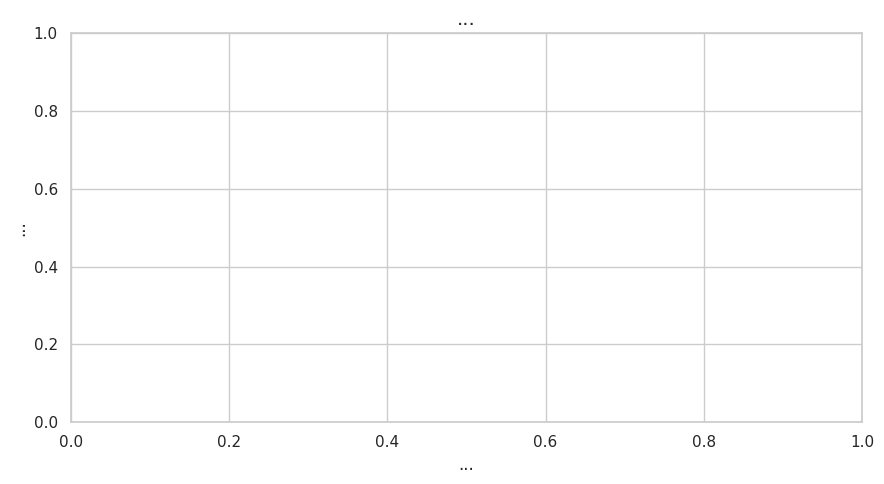

In [ ]:
# Actividad 1a — Histograma con Matplotlib
fig, ax = plt.subplots(figsize=(9, 5))

# TU CÓDIGO AQUÍ




ax.set_title('...')   # ← completá el título
ax.set_xlabel('...')  # ← etiqueta eje X
ax.set_ylabel('...')  # ← etiqueta eje Y
plt.tight_layout()
plt.show()


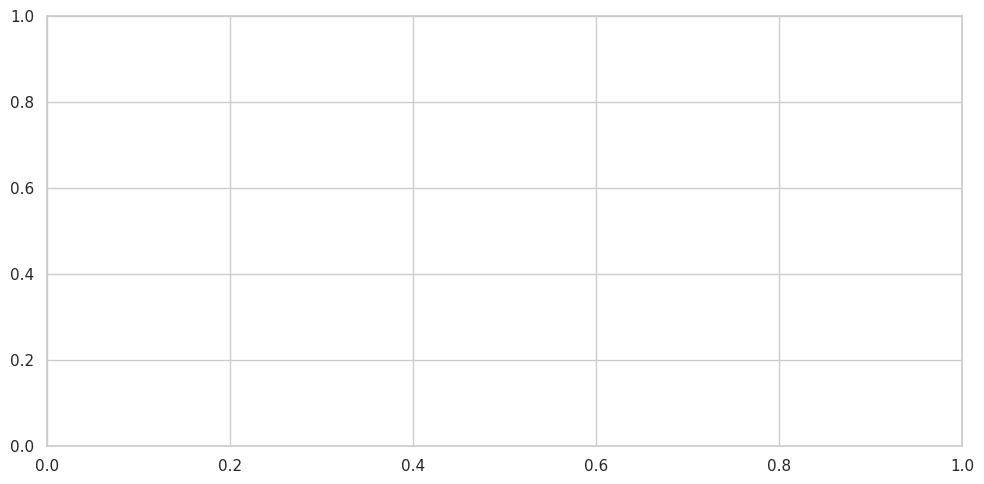

In [ ]:
# Actividad 1b — Histograma con Seaborn diferenciado por clase
fig, ax = plt.subplots(figsize=(10, 5))

# TU CÓDIGO AQUÍ




plt.tight_layout()
plt.show()


**Análisis 1 — Respondé aquí:**

- ¿La distribución de edades es simétrica, sesgada a la derecha o sesgada a la izquierda? ¿Cómo lo determinás?
- ¿Hay diferencias en la distribución de edades entre las distintas clases del barco?
- ¿Qué grupo etario es el más numeroso? ¿Y el menos representado?

*Escribí tu análisis en esta celda.*


## 🔵 Actividad 2 — Boxplot para Comparar Grupos

Usá el dataset `tips` para crear:

**2a.** Un boxplot con Seaborn que muestre la distribución de `tip` (propina) separada por el día (`day`).  
**2b.** Un violinplot del mismo dataset que muestre `total_bill` por `day`, diferenciado por `time` (Lunch/Dinner) usando `hue`.

¿Cuál es el día con mayor mediana de propina? ¿Y el día con mayor variabilidad?


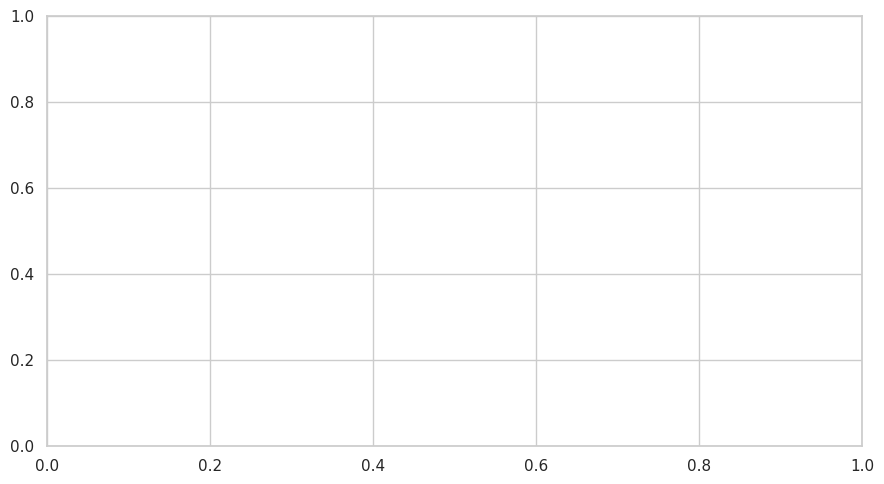

In [ ]:
# Actividad 2a — Boxplot de propinas por día
fig, ax = plt.subplots(figsize=(9, 5))

# TU CÓDIGO AQUÍ




plt.tight_layout()
plt.show()


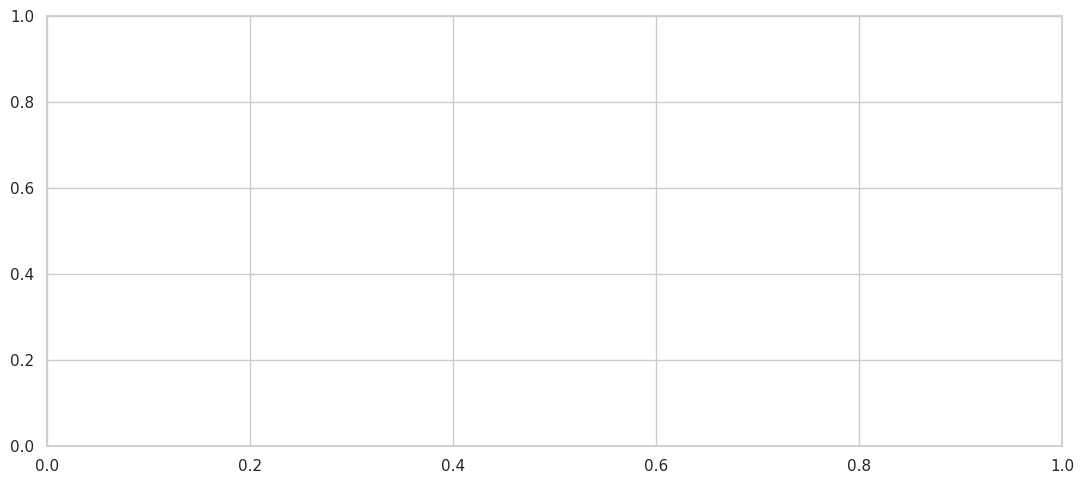

In [ ]:
# Actividad 2b — Violinplot de factura total por día y momento
fig, ax = plt.subplots(figsize=(11, 5))

# TU CÓDIGO AQUÍ




plt.tight_layout()
plt.show()


**Análisis 2 — Respondé aquí:**

- ¿En qué día se registra la propina **mediana** más alta?
- ¿Qué día presenta la mayor **variabilidad** en el monto de la propina? ¿Cómo lo identificás en el boxplot?
- ¿Hay outliers visibles? ¿En qué día aparecen?
- ¿Qué diferencias notás entre Lunch y Dinner en el violinplot?

*Escribí tu análisis en esta celda.*


## 🔵 Actividad 3 — Scatter Plot y Correlación

Usando el dataset `tips`:

**3a.** Creá un scatter plot de `total_bill` vs `tip`. Usá `hue='sex'` y `style='smoker'`.  
**3b.** Calculá la correlación de Pearson entre `total_bill` y `tip`. Mostrá el valor en el título del gráfico.  
**3c.** Agregá una línea de tendencia (regresión lineal) al scatter usando `sns.regplot`.


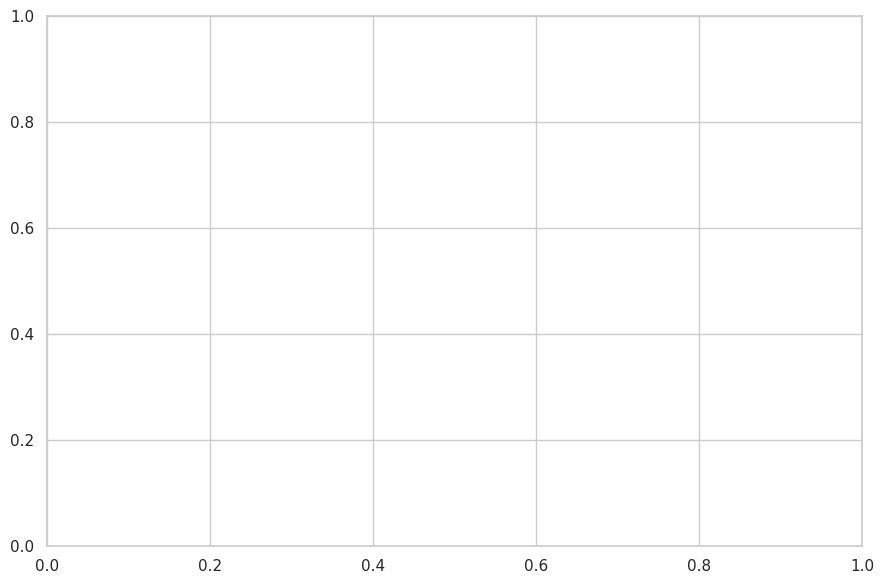

In [ ]:
# Actividad 3a — Scatter con múltiples dimensiones
fig, ax = plt.subplots(figsize=(9, 6))

# TU CÓDIGO AQUÍ




plt.tight_layout()
plt.show()


Correlación de Pearson (total_bill, tip): 0.6757


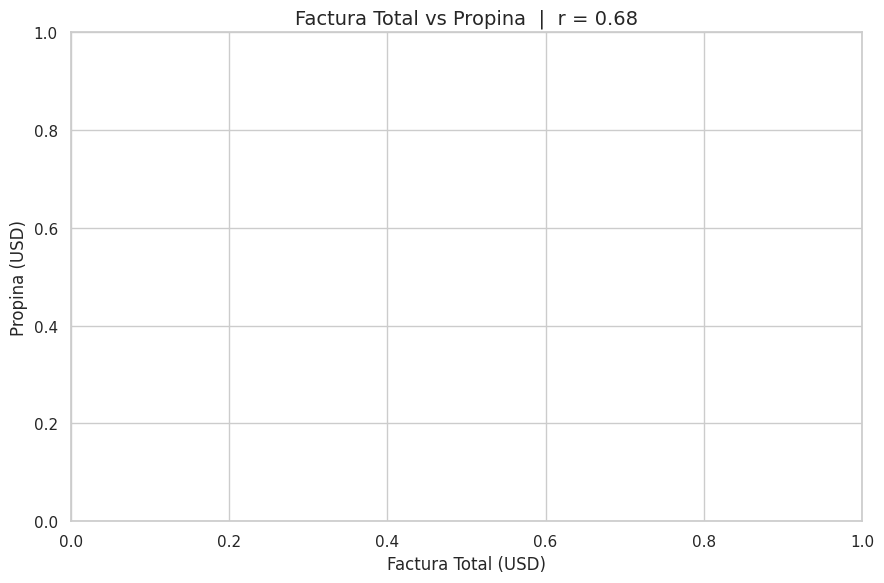

In [ ]:
# Actividad 3b — Calcular correlación y mostrarla en el gráfico
correlacion = tips[['total_bill', 'tip']].corr().iloc[0, 1]
print(f"Correlación de Pearson (total_bill, tip): {correlacion:.4f}")

# Actividad 3c — Agregar línea de regresión con sns.regplot
fig, ax = plt.subplots(figsize=(9, 6))

# TU CÓDIGO AQUÍ — usá sns.regplot




ax.set_title(f'Factura Total vs Propina  |  r = {correlacion:.2f}')
ax.set_xlabel('Factura Total (USD)')
ax.set_ylabel('Propina (USD)')
plt.tight_layout()
plt.show()


**Análisis 3 — Respondé aquí:**

- ¿Qué tipo de correlación hay entre la factura total y la propina? ¿Es esperado ese resultado?
- ¿Hay diferencias visibles entre hombres y mujeres o entre fumadores y no fumadores?
- ¿La relación parece lineal o hay algún patrón más complejo?

*Escribí tu análisis en esta celda.*


## 🔵 Actividad 4 — Heatmap de Correlación

Usando el dataset `titanic`:

**4a.** Calculá la matriz de correlación para todas las variables numéricas.  
**4b.** Visualizala con `sns.heatmap` con anotaciones, usando la paleta `coolwarm`.  
**4c.** Identificá el par de variables con **mayor correlación positiva** y el par con **mayor correlación negativa**.


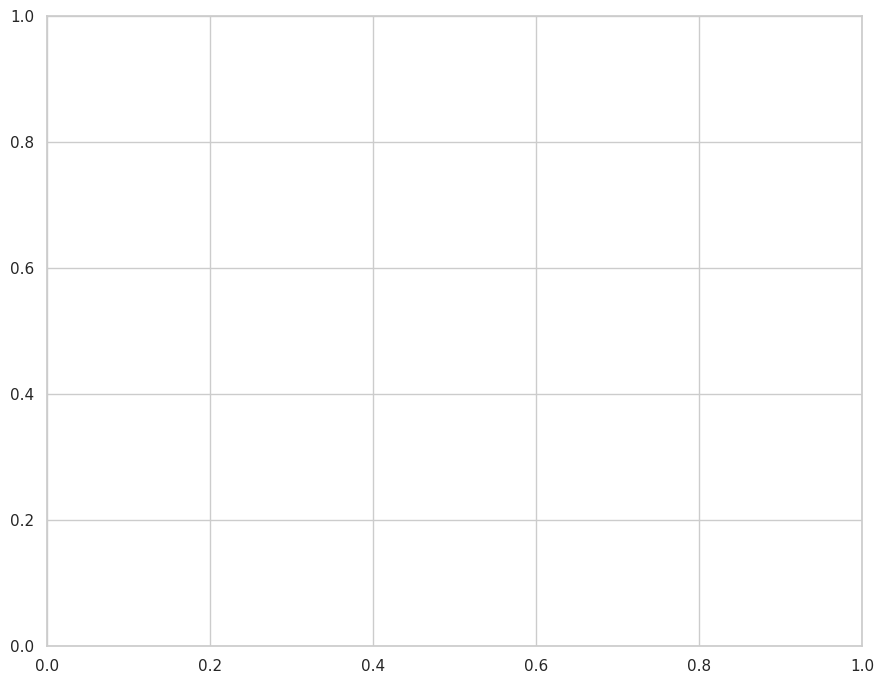

In [ ]:
# Actividad 4 — Heatmap de correlación del Titanic
fig, ax = plt.subplots(figsize=(9, 7))

# TU CÓDIGO AQUÍ — calculá la matriz de correlación y crea el heatmap




plt.tight_layout()
plt.show()

# Identificar pares de mayor y menor correlación (excluir diagonal)
# TU CÓDIGO AQUÍ


**Análisis 4 — Respondé aquí:**

- ¿Qué par de variables tiene la correlación positiva más fuerte? ¿Tiene sentido desde el dominio?
- ¿Qué par tiene la correlación negativa más fuerte? ¿Qué podría explicarlo?
- ¿La variable `survived` está correlacionada con `pclass`? ¿Qué nos dice eso sobre el desastre del Titanic?

*Escribí tu análisis en esta celda.*


## 🟠 Actividad 5 (DESAFÍO) — Dashboard de Visualización

Creá una figura con **4 subplots** usando `plt.subplots(2, 2)` que presente un análisis completo del dataset `titanic`.  
Cada subplot debe responder una pregunta de negocio diferente:

1. *(superior izquierda)* Distribución de edades por clase (`sns.histplot` con `hue='pclass'`)
2. *(superior derecha)* Distribución de tarifas por supervivencia (`sns.boxplot`)
3. *(inferior izquierda)* Edad vs Tarifa coloreado por supervivencia (`sns.scatterplot`)
4. *(inferior derecha)* Tasa de supervivencia por clase (gráfico de barras con `value_counts`)

Cada subplot debe tener título, etiquetas, leyenda cuando corresponda y un tamaño adecuado.


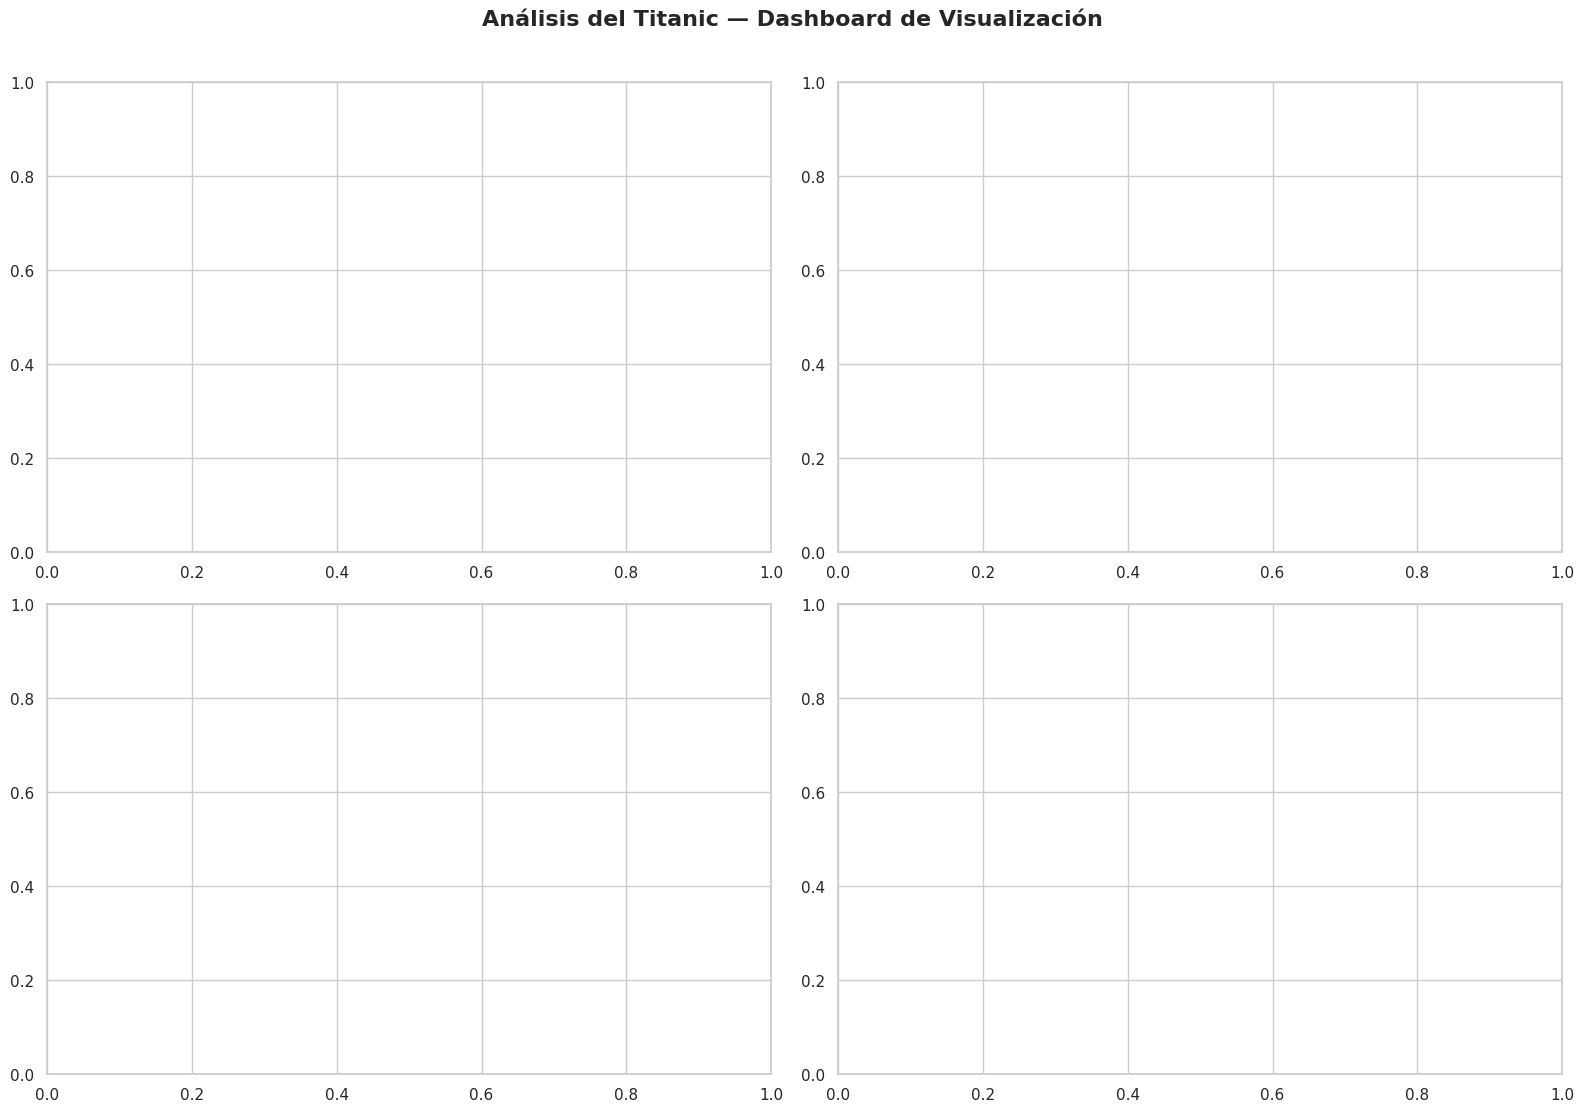

In [ ]:
# Actividad 5 — Dashboard del Titanic
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Análisis del Titanic — Dashboard de Visualización',
             fontsize=16, fontweight='bold', y=1.01)

# Subplot (0,0) — Distribución de edades por clase
# TU CÓDIGO AQUÍ



# Subplot (0,1) — Distribución de tarifas por supervivencia
# TU CÓDIGO AQUÍ



# Subplot (1,0) — Edad vs Tarifa por supervivencia
# TU CÓDIGO AQUÍ



# Subplot (1,1) — Tasa de supervivencia por clase
# TU CÓDIGO AQUÍ



plt.tight_layout()
plt.show()


**Análisis 5 — Reflexión final:**

Mirando el dashboard completo, escribí un **párrafo de análisis** (4-6 oraciones) que integre lo que observás en los cuatro gráficos.  
¿Qué factores parecen haber influido más en la supervivencia de los pasajeros del Titanic según las visualizaciones?

*Escribí tu análisis aquí.*

---

> **Recordatorio:** Compartí este notebook en el foro de Moodle antes de la Clase 9.  
> Comentá el trabajo de al menos un compañero mencionando algo que te haya resultado interesante de su análisis.
